# Sleep-stage classification — EDA (Kaggle `inception`)

**Task:** predict `sleep_stage` for each epoch in the test set. **Metric:** macro-F1.

This notebook profiles the dataset and surfaces the problems that matter for modeling, with concrete fixes. Key findings are summarized at the bottom.

In [2]:
import numpy as np, pandas as pd
import matplotlib.pyplot as plt, seaborn as sns
pd.set_option('display.width', 140); pd.set_option('display.max_columns', 30)

train = pd.read_csv('train.csv')
test  = pd.read_csv('test.csv')
sample = pd.read_csv('sample_submission.csv')

FEATURES = [c for c in train.columns if c not in ('id', 'sleep_stage')]
TARGET   = 'sleep_stage'
print('train', train.shape, '| test', test.shape, '| #features', len(FEATURES))
print('train id range', train.id.min(), '-', train.id.max())
print('test  id range', test.id.min(),  '-', test.id.max())
train.head()

train (9000, 23) | test (5000, 22) | #features 21
train id range 0 - 8999
test  id range 9000 - 13999


,id,eeg_delta_power,eeg_theta_power,eeg_alpha_power,eeg_sigma_power,eeg_beta_power,eeg_gamma_power,eeg_slow_osc_power,eeg_spectral_entropy,eeg_spindle_density,eeg_kcomplex_rate,emg_chin_tone,emg_tone_variance,eog_movement_density,eog_amplitude,heart_rate_mean,heart_rate_variability,respiration_rate,respiration_variability,spo2_mean,body_movement_index,eog_burst_index,sleep_stage
0,0,-1.51474,1.40728,10.33510,-1.61350,3.73081,0.99850,1.85689,-3.24253,-1.27096,-1.66370,2.79720,-1.76807,2.65567,1.98733,1.60184,-2.49794,-0.59521,1.71154,1.93342,1.57365,-1.36230,1
1,1,-0.28998,0.89706,1.62494,2.41580,-2.70265,-0.10131,-1.68955,0.01442,-2.87943,-0.03516,0.66264,-0.35469,4.36423,0.09942,3.38567,-0.56386,2.16016,-4.32301,1.07270,-2.43903,-0.37271,2
2,2,3.35435,0.32987,-5.41547,2.38680,-2.90584,-2.93372,-3.11713,-0.04647,1.61782,-0.53028,-2.08711,1.49050,-3.87561,-0.87681,-2.84480,5.08383,-4.60411,0.37967,-2.06913,2.67324,NaN,3
3,3,-1.44917,-0.04374,1.71560,-1.27770,-0.19007,2.21826,1.69621,0.39756,0.00534,-0.65535,0.98192,1.12176,1.41415,0.39275,0.55060,-2.12910,2.32790,0.78319,0.98233,1.53824,-0.25040,1
4,4,1.35898,-2.36720,-7.40779,5.31815,-2.55954,-5.13284,-5.26634,1.73985,1.04618,-1.04615,-2.74524,-0.31044,-0.55616,0.86588,-1.96343,4.30036,0.22130,-1.44020,1.35760,-3.07701,-1.04947,3


train (9000, 23) | test (5000, 22) | #features 21
train id range 0 - 8999
test  id range 9000 - 13999


,id,eeg_delta_power,eeg_theta_power,eeg_alpha_power,eeg_sigma_power,eeg_beta_power,eeg_gamma_power,eeg_slow_osc_power,eeg_spectral_entropy,eeg_spindle_density,eeg_kcomplex_rate,emg_chin_tone,emg_tone_variance,eog_movement_density,eog_amplitude,heart_rate_mean,heart_rate_variability,respiration_rate,respiration_variability,spo2_mean,body_movement_index,eog_burst_index,sleep_stage
0,0,-1.51474,1.40728,10.33510,-1.61350,3.73081,0.99850,1.85689,-3.24253,-1.27096,-1.66370,2.79720,-1.76807,2.65567,1.98733,1.60184,-2.49794,-0.59521,1.71154,1.93342,1.57365,-1.36230,1
1,1,-0.28998,0.89706,1.62494,2.41580,-2.70265,-0.10131,-1.68955,0.01442,-2.87943,-0.03516,0.66264,-0.35469,4.36423,0.09942,3.38567,-0.56386,2.16016,-4.32301,1.07270,-2.43903,-0.37271,2
2,2,3.35435,0.32987,-5.41547,2.38680,-2.90584,-2.93372,-3.11713,-0.04647,1.61782,-0.53028,-2.08711,1.49050,-3.87561,-0.87681,-2.84480,5.08383,-4.60411,0.37967,-2.06913,2.67324,NaN,3
3,3,-1.44917,-0.04374,1.71560,-1.27770,-0.19007,2.21826,1.69621,0.39756,0.00534,-0.65535,0.98192,1.12176,1.41415,0.39275,0.55060,-2.12910,2.32790,0.78319,0.98233,1.53824,-0.25040,1
4,4,1.35898,-2.36720,-7.40779,5.31815,-2.55954,-5.13284,-5.26634,1.73985,1.04618,-1.04615,-2.74524,-0.31044,-0.55616,0.86588,-1.96343,4.30036,0.22130,-1.44020,1.35760,-3.07701,-1.04947,3


## 1. Target distribution
4 classes (0–3), nearly balanced. With macro-F1 every class counts equally, so balance is good news — no resampling needed, but the hardest class drags the score the most.

sleep_stage
0    2001
1    2442
2    2237
3    2320
Name: count, dtype: int64

share %:
sleep_stage
0    22.23
1    27.13
2    24.86
3    25.78
Name: count, dtype: float64


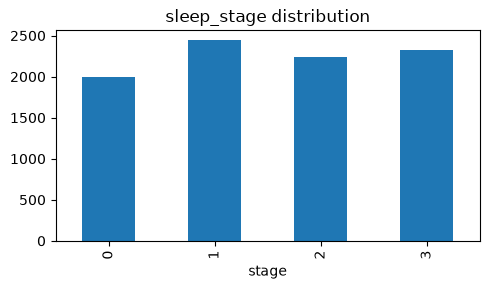

In [2]:
vc = train[TARGET].value_counts().sort_index()
print(vc); print('\nshare %:'); print((vc/len(train)*100).round(2))
ax = vc.plot(kind='bar', figsize=(5,3), title='sleep_stage distribution'); ax.set_xlabel('stage'); plt.tight_layout(); plt.show()

## 2. Missing values
Only **one** column has NaNs — `eog_burst_index` — and it is missing for ~**50%** of rows in *both* train and test. We check whether the missingness carries signal (correlates with the class) or is random (MCAR).

In [3]:
print('NaNs per column (train):'); print(train[FEATURES].isna().sum()[lambda s: s>0])
print('\noverall miss rate  train=%.3f  test=%.3f' % (train.eog_burst_index.isna().mean(), test.eog_burst_index.isna().mean()))
print('\nmiss rate of eog_burst_index BY class:')
print(train.assign(miss=train.eog_burst_index.isna()).groupby(TARGET).miss.mean().round(3))

NaNs per column (train):
eog_burst_index    4501
dtype: int64

overall miss rate  train=0.500  test=0.495

miss rate of eog_burst_index BY class:
sleep_stage
0    0.486
1    0.496
2    0.504
3    0.512
Name: miss, dtype: float64


The miss rate is ~0.49–0.51 across **all** classes ⇒ missingness is essentially random (MCAR), it does **not** encode the label. So a "missing" indicator column is not expected to help (confirmed in §5).

**Fixes:** prefer a model with native NaN handling (HistGradientBoosting / LightGBM / XGBoost) — no imputation needed. For linear/distance models, median-impute. Do **not** drop the rows (you'd lose half the data) and do **not** drop the column (it is one of the most discriminative features, §4).

In [4]:
# train vs test feature distributions -> check for distribution shift
desc = train[FEATURES].describe().T[['mean','std','min','max']]
desc['test_mean'] = test[FEATURES].mean(); desc['test_std'] = test[FEATURES].std()
desc.round(3)

,mean,std,min,max,test_mean,test_std
eeg_delta_power,-0.015,2.431,-9.567,8.798,-0.033,2.430
eeg_theta_power,-0.034,2.408,-8.277,9.222,0.009,2.401
eeg_alpha_power,-0.016,5.042,-20.632,18.870,-0.091,5.002
eeg_sigma_power,0.012,2.207,-7.948,9.603,-0.009,2.206
eeg_beta_power,-0.010,2.883,-11.460,10.027,-0.030,2.845
eeg_gamma_power,-0.011,2.428,-9.638,8.296,0.011,2.450
eeg_slow_osc_power,-0.014,2.801,-14.123,10.362,0.001,2.782
eeg_spectral_entropy,0.010,2.753,-9.301,10.160,0.071,2.705
eeg_spindle_density,0.006,2.174,-8.828,8.937,0.004,2.198
eeg_kcomplex_rate,0.007,1.948,-8.090,7.064,0.042,1.965


All features are already centered near 0 (pre-standardized signals) but with **different spreads** (std ~1.0 to ~5.0). Tree models don't care; for linear/SVM/kNN/NN apply `StandardScaler`. `eog_burst_index` is the only feature on a tight, symmetric [-3.94, 3.94] scale — a hint it was generated/clipped differently. Train and test means/stds match closely ⇒ **no covariate shift**, so local CV should track the leaderboard.

## 3. Feature correlations
Several physiological features are strongly correlated (up to ~0.82). Harmless for trees; for linear models consider regularization or dropping redundant pairs.

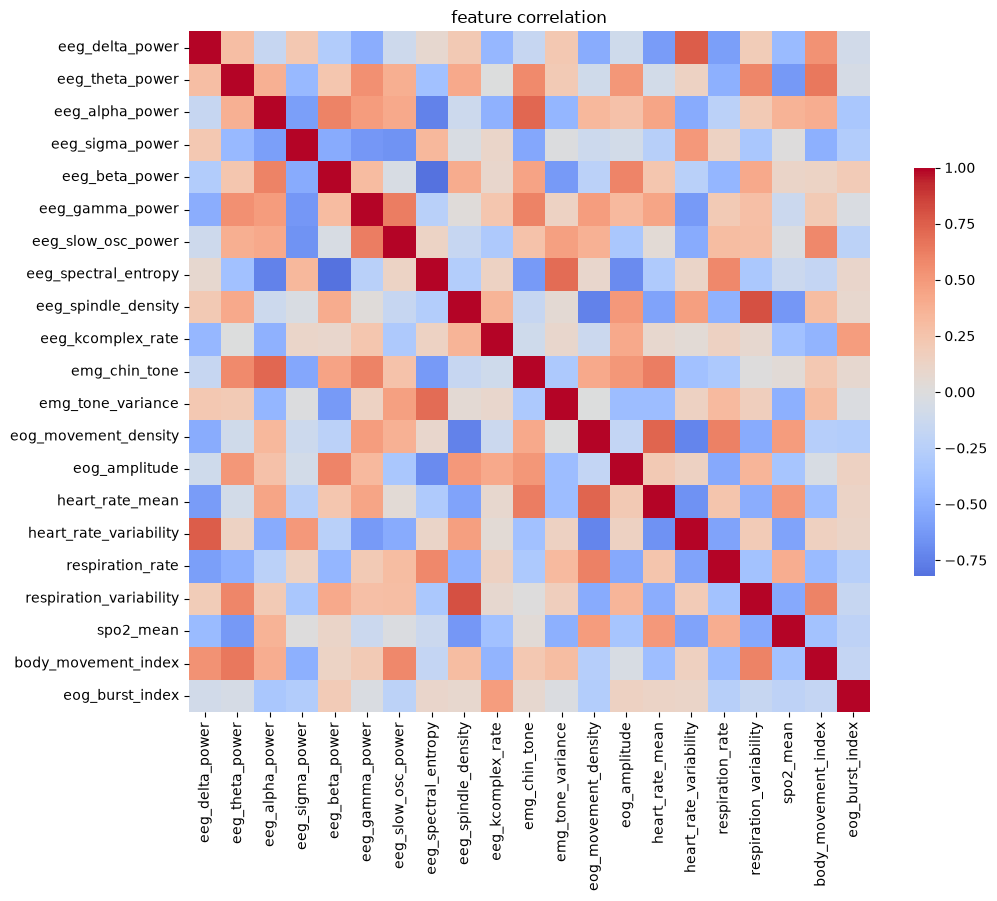

top correlated pairs:
eeg_beta_power           eeg_spectral_entropy    0.821
respiration_variability  eeg_spindle_density     0.802
heart_rate_variability   eeg_delta_power         0.760
eeg_alpha_power          eeg_spectral_entropy    0.750
eeg_spindle_density      eog_movement_density    0.743
eog_movement_density     heart_rate_mean         0.729
heart_rate_variability   eog_movement_density    0.726
emg_chin_tone            eeg_alpha_power         0.722
dtype: float64


In [5]:
corr = train[FEATURES].corr()
plt.figure(figsize=(11,9)); sns.heatmap(corr, cmap='coolwarm', center=0, square=True, cbar_kws={'shrink':0.6})
plt.title('feature correlation'); plt.tight_layout(); plt.show()
a = corr.abs()
for i in range(len(a)): a.iat[i, i] = 0
print('top correlated pairs:'); print(a.unstack().sort_values(ascending=False).drop_duplicates().head(8).round(3))

## 4. Class separability — which features carry the signal?
ANOVA F-score per feature (how strongly each separates the 4 stages).

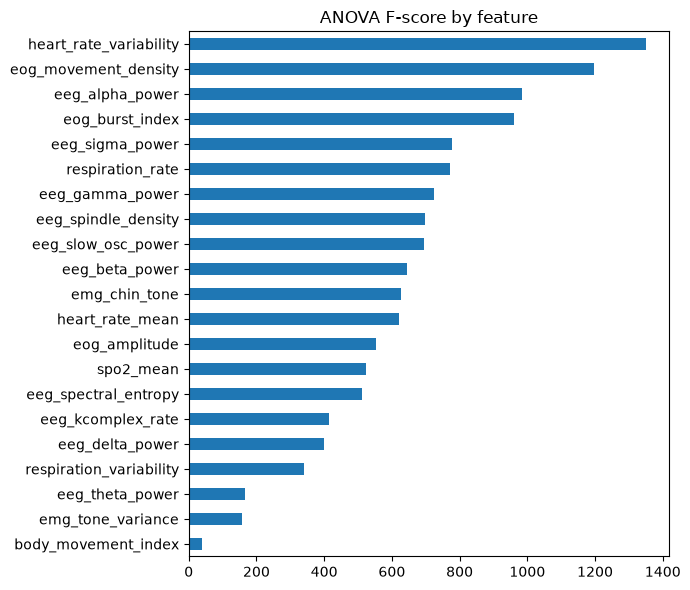

weakest features: ['body_movement_index', 'emg_tone_variance', 'eeg_theta_power']


In [6]:
from sklearn.feature_selection import f_classif
Xi = train[FEATURES].fillna(train[FEATURES].median())
F, _ = f_classif(Xi, train[TARGET])
imp = pd.Series(F, index=FEATURES).sort_values()
imp.plot(kind='barh', figsize=(7,6), title='ANOVA F-score by feature'); plt.tight_layout(); plt.show()
print('weakest features:', list(imp.index[:3]))

In [7]:
# per-class mean (z-scored) of the most discriminative features -> physiological fingerprint of each stage
z = (train[FEATURES] - train[FEATURES].mean()) / train[FEATURES].std()
key = ['heart_rate_variability','eog_movement_density','eeg_alpha_power','eeg_sigma_power','emg_chin_tone','eeg_delta_power','eog_burst_index']
z.assign(stage=train[TARGET]).groupby('stage')[key].mean().round(2).T

stage,0,1,2,3
heart_rate_variability,0.63,-0.74,-0.24,0.47
eog_movement_density,-0.81,0.56,0.38,-0.26
eeg_alpha_power,-0.34,0.81,-0.19,-0.37
eeg_sigma_power,-0.14,-0.40,-0.22,0.75
emg_chin_tone,0.11,0.45,0.10,-0.66
eeg_delta_power,0.25,-0.48,-0.11,0.39
eog_burst_index,0.96,-0.61,0.47,-0.67


Each stage has a clear multivariate fingerprint (e.g. one stage = high alpha + high EOG movement + high chin tone, wake-like; another = high sigma/spindle + low chin tone, deeper sleep). `body_movement_index`, `emg_tone_variance`, `eeg_theta_power` are the weakest single features but can still help in combination — don't prune blindly.

## 5. Baseline models (5-fold CV, macro-F1)
Chance ≈ 0.25. This sets the bar before tuning.

In [8]:
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

cv = StratifiedKFold(5, shuffle=True, random_state=42)
y = train[TARGET]
Xmed = train[FEATURES].fillna(train[FEATURES].median())

def bench(name, model, X):
    s = cross_val_score(model, X, y, cv=cv, scoring='f1_macro')
    print(f'{name:32s} macroF1 = {s.mean():.4f} +/- {s.std():.4f}')

bench('LogReg (scaled, median-imp)', make_pipeline(StandardScaler(), LogisticRegression(max_iter=2000)), Xmed)
bench('RandomForest (median-imp)',   RandomForestClassifier(n_estimators=400, random_state=42, n_jobs=-1), Xmed)
bench('HistGBM (native NaN)',        HistGradientBoostingClassifier(random_state=42, max_iter=400, learning_rate=0.05), train[FEATURES])

# does a missing-indicator for eog_burst_index help? (expected: no, since MCAR)
X2 = train[FEATURES].copy(); X2['eog_burst_missing'] = train.eog_burst_index.isna().astype(int)
bench('HistGBM + miss-indicator',    HistGradientBoostingClassifier(random_state=42, max_iter=400, learning_rate=0.05), X2)

LogReg (scaled, median-imp)      macroF1 = 0.7453 +/- 0.0075


RandomForest (median-imp)        macroF1 = 0.7972 +/- 0.0050


HistGBM (native NaN)             macroF1 = 0.8132 +/- 0.0051


HistGBM + miss-indicator         macroF1 = 0.8132 +/- 0.0051


## 6. Where the errors are — confusion matrix
Out-of-fold predictions from the HistGBM baseline.

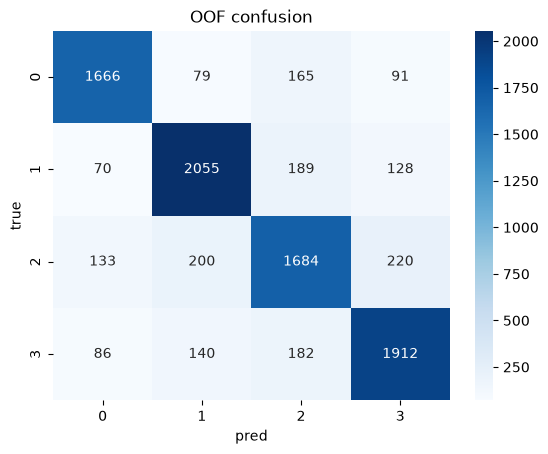

              precision    recall  f1-score   support

           0      0.852     0.833     0.842      2001
           1      0.831     0.842     0.836      2442
           2      0.759     0.753     0.756      2237
           3      0.813     0.824     0.819      2320

    accuracy                          0.813      9000
   macro avg      0.814     0.813     0.813      9000
weighted avg      0.813     0.813     0.813      9000



In [9]:
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import confusion_matrix, classification_report
oof = cross_val_predict(HistGradientBoostingClassifier(random_state=42, max_iter=400, learning_rate=0.05), train[FEATURES], y, cv=cv)
cm = confusion_matrix(y, oof)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues'); plt.xlabel('pred'); plt.ylabel('true'); plt.title('OOF confusion'); plt.show()
print(classification_report(y, oof, digits=3))

**Class 2 is the bottleneck** (F1 ≈ 0.76 vs ~0.82–0.84 for the others), confused mostly with classes 1 and 3 — a transitional/intermediate stage. Because macro-F1 weights classes equally, lifting class 2 is the single highest-leverage improvement.

---
## Summary — problems & fixes

| # | Observation | Risk for models | Fix |
|---|---|---|---|
| 1 | `eog_burst_index` ~50% NaN (train & test), MCAR | Imputation distorts a strong feature; linear/kNN/NN can't take NaN | Native-NaN trees (HistGBM/LightGBM/XGBoost); else median-impute. Keep the column. Missing-indicator doesn't help. |
| 2 | Features pre-scaled but std varies 1–5 | Hurts LogReg/SVM/kNN/NN | `StandardScaler` for non-tree models; trees fine as-is |
| 3 | Strong multicollinearity (up to 0.82) | Unstable linear coefficients | Regularize or drop redundant pairs; irrelevant for trees |
| 4 | Class 2 hardest (overlaps 1 & 3) | Caps macro-F1 | Tuned GBMs, probability calibration + per-class threshold tuning, ensembling |
| 5 | Classes balanced (22–27%) | — | No resampling needed; use StratifiedKFold |
| 6 | No train/test shift, no dup rows | — | Trust local 5-fold CV as a leaderboard proxy |

**Recommended path:** start from the HistGBM baseline (~0.81 macro-F1), then tune LightGBM/XGBoost, add feature interactions aimed at class 2, calibrate probabilities and tune decision thresholds for macro-F1, and finally ensemble (GBM + RF + LogReg). Always validate with the same StratifiedKFold split.